<a href="https://colab.research.google.com/github/Juanezm/ml-model-battery-levels-iot/blob/main/scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Escenario 1**: Conjuntos de datos de entrenamiento y prueba separados  
#### En este primer escenario, el modelo se entrena utilizando el conjunto de datos 1, reservando el 20% de los datos para validación.
#### La prueba se realiza utilizando el conjunto de datos 0.
#### Este método evalúa la capacidad del modelo cuando es entrenado y probado en diferentes conjuntos de datos.

In [1]:
# Primero
#id_train = "270043001951343334363036"
#id_test = "46004e000251353337353037"

In [2]:
# Segundo
#id_train = "4e0031000251353337353037"
#id_test = "46004e000251353337353037"

In [3]:
# Tercero
#id_train = "200034001951343334363036 "
#id_test = "46005a000351353337353037"

In [4]:
# Cuarto
id_train = "380033001951343334363036"
id_test = "46005a000351353337353037"

In [5]:
import pandas as pd
import numpy as np
import os

import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional, TimeDistributed, Conv1D, Flatten, MaxPooling1D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

from IPython.display import clear_output
from IPython.display import HTML
#import imgkit

2024-12-11 18:40:05.194223: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Variables a definir

In [6]:
seq_length = 72 #120
forecast_steps = seq_length
future_steps = 1
intervalo = "15min"

In [7]:
quitar = ["soil_humidity"]
re_sample = "1H"
cut_train = 0
cut_test = 0

#### Función para normalizar los datos

In [8]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

In [61]:
def forecast_battery_consumption(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y):
    """
    This function is used to forecast battery consumption based on historical data.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model (model): model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    matplotlib.pyplot: Plot of actual vs forecasted battery consumption.
    """

    # Inicialización de las variables
    # Los 120 primeros valores del dataframe test_dataset con 9 var, fecha y battery como columnas de variables
    historical_data = test[:seq_length+1]
    # Los siguientes 120 valores del dataframe test_dataset, con las 9 variables igual, sobre el que hacemos la predicción
    forecast_data = test[seq_length:seq_length+forecast_steps]
    # Quitamos battery pero no fechas
    weather_forecast = forecast_data.drop(columns=['battery']) # Eliminamos la columna battery que se reemplaza por las predicciones
    # Insertamos una columna battery llena de Nan
    weather_forecast['battery'] = np.nan
    # Inicialmente de 0 hasta 120, son lo que se usan para las predicciones
    updated_historical_data = historical_data

    for steps in range(0, forecast_steps, future_steps): # desde 0 hasta 119 en pasos de 0 --> 119 pasos

        # normalise historical_data
        # update_historical_data tiene la última previsión incorporada para seguir haciendo predicciones
        X_hist, y_hist = normalise_data(
                                        scaler_x,
                                        updated_historical_data.drop(columns=['fecha']), # Va todo incluida la columna de battery
                                        #updated_historical_data.drop(columns=['fecha', "battery"]),
                                        scaler_y,
                                        updated_historical_data['battery'])

        # create sequences out of historical_data
        X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

        # predict next battery level
        # next_battery_pred = y_pred
        next_battery_pred = model.predict(X_hist_seq)
        #evaluar = model.evaluate(X_hist_seq, y_hist_seq)
        clear_output(wait=True) # limpiar la salida de la celda actual, permitiendo actualizar la información mostrada en lugar de acumularla.


        # inverse normalisation of predicted battery level
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

        # Add predicted value to weather forecast
        # Las predicciones están en weather forecast
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv

        # Update the historical data with the forecasted
        updated_historical_data = pd.concat([updated_historical_data[future_steps:], weather_forecast[steps:steps+future_steps]], ignore_index=True)


    # Plot actual vs predicted with dates
    plt.figure(figsize=(20, 6))

    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Historic')
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Forecast', marker=".")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker=".")
    plt.title('Actual vs Forecasted Battery Consumption')
    plt.xlabel('Time')
    plt.ylabel('Battery Consumption')
    plt.legend()
    plt.grid()
    plt.show()

    print('RMSE: ', root_mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MSE:  ', mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MAE:  ', mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))

    return historical_data, weather_forecast, forecast_data, updated_historical_data

In [9]:
def create_sequences(X, y, seq_length):
    xs = []
    ys = []

    for i in range(len(X)-seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length])

    return np.array(xs), np.array(ys)

### Cargamos el conjunto de datos según lo definido al principio

In [11]:
# Load data
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037",
]

In [12]:
#from google.colab import drive
#drive.mount('/content/drive')

In [13]:
completos_dir = "../src/datos"
data_origen = "../src/data_download"
#completos_dir = "/content/drive/My Drive/TFM/datos"

In [14]:
sensors_data_clean = {id: pd.read_csv(f"{completos_dir}/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

In [15]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [16]:
print('Number of trainning sets: ', len(train_dataset))
print('Number of testing sets: ', len(test_dataset))

Number of trainning sets:  12429
Number of testing sets:  3834


In [17]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12429 entries, 2018-05-12 00:00:00 to 2018-09-19 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    12429 non-null  float64
 1   pressure       12429 non-null  float64
 2   battery        12429 non-null  float64
 3   air_humidity   12429 non-null  float64
 4   soil_humidity  12429 non-null  float64
 5   wind_speed     12429 non-null  float64
 6   irradiancia    12429 non-null  float64
 7   minutos_dia    12429 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 873.9 KB


In [18]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3834 entries, 2018-08-24 00:00:00 to 2018-10-03 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    3834 non-null   float64
 1   pressure       3834 non-null   float64
 2   battery        3834 non-null   float64
 3   air_humidity   3834 non-null   float64
 4   soil_humidity  3834 non-null   float64
 5   wind_speed     3834 non-null   float64
 6   irradiancia    3834 non-null   float64
 7   minutos_dia    3834 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 269.6 KB


In [19]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-05-12 00:00:00,17.24,978.77,79.12,65.42,35.17,2.41,0.0,861
2018-05-12 00:15:00,16.78,978.58,77.98,63.22,47.00,2.41,0.0,861
2018-05-12 00:30:00,16.44,978.39,77.48,64.24,67.78,2.41,0.0,861
2018-05-12 00:45:00,15.93,978.57,76.67,64.75,37.40,2.41,0.0,861
2018-05-12 01:00:00,15.69,978.55,76.18,64.95,34.57,2.41,0.0,861


In [20]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-08-24 00:00:00,22.46,986.00,70.94,60.43,69.66,2.41,0.0,807
2018-08-24 00:15:00,22.22,986.00,70.61,59.96,69.33,2.41,0.0,807
2018-08-24 00:30:00,21.84,986.14,70.28,60.01,69.33,0.00,0.0,807
2018-08-24 00:45:00,21.69,986.01,70.12,60.60,69.37,0.00,0.0,807
2018-08-24 01:00:00,21.29,986.32,69.62,60.81,69.58,0.00,0.0,807


#### Alineación de puntos de datos según marcas de tiempo

In [21]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

In [22]:
train_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-08-05 02:00:00,24.1850,978.8700,67.155,47.6225,69.2550,1.2050,0.00,851.0
2018-07-27 19:00:00,37.1975,974.0625,84.050,34.0850,63.8625,8.4450,0.00,869.0
2018-06-25 05:00:00,18.2825,977.9275,61.010,78.5350,74.9200,0.0000,100.35,905.0
2018-07-15 17:00:00,36.2250,975.1525,81.685,36.9000,74.2050,5.7275,227.10,888.0
2018-05-29 02:00:00,14.4500,976.3725,68.565,78.4400,67.8900,1.8075,0.00,889.0


In [23]:
test_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-09-10 09:00:00,21.7125,992.4025,33.8600,77.8450,24.0025,1.8075,338.51,764.0
2018-09-02 17:00:00,32.8150,984.3725,79.6075,59.0350,71.4450,4.2200,101.26,785.0
2018-09-14 00:00:00,20.5100,988.8550,65.0225,79.3325,23.7050,1.2050,0.00,754.0
2018-08-24 22:00:00,23.2475,985.7900,72.1250,75.2875,68.7625,1.2050,0.00,807.0
2018-09-17 11:00:00,34.8825,990.1975,80.9925,70.2150,32.4675,1.8075,720.13,746.0


In [24]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [25]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-05-12 00:00:00,16.5975,978.5775,77.8125,64.4075,46.8375,2.4100,0.0,861.0
1,2018-05-12 01:00:00,15.2675,978.3375,75.2425,66.5050,35.1800,0.6025,0.0,861.0
2,2018-05-12 02:00:00,14.8075,977.9550,73.3150,68.4800,41.4825,1.2050,0.0,861.0
3,2018-05-12 03:00:00,14.6425,977.3175,71.8400,73.2350,40.1800,1.2050,0.0,861.0
4,2018-05-12 04:00:00,15.9075,976.8150,70.6900,74.8675,30.6275,2.4100,0.0,861.0


In [26]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0


In [27]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [28]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-12 00:00:00,16.5975,978.5775,77.8125,64.4075,46.8375,2.4100,0.0,861.0,0
1,2018-05-12 01:00:00,15.2675,978.3375,75.2425,66.5050,35.1800,0.6025,0.0,861.0,1
2,2018-05-12 02:00:00,14.8075,977.9550,73.3150,68.4800,41.4825,1.2050,0.0,861.0,2
3,2018-05-12 03:00:00,14.6425,977.3175,71.8400,73.2350,40.1800,1.2050,0.0,861.0,3
4,2018-05-12 04:00:00,15.9075,976.8150,70.6900,74.8675,30.6275,2.4100,0.0,861.0,4


In [29]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0,4


In [30]:
# Drop variables not available from Open Weather API forecast
train_dataset = train_dataset.drop(columns=quitar)
test_dataset = test_dataset.drop(columns=quitar)

In [31]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-05-12 00:00:00,16.5975,978.5775,77.8125,64.4075,2.4100,0.0,861.0,0
1,2018-05-12 01:00:00,15.2675,978.3375,75.2425,66.5050,0.6025,0.0,861.0,1
2,2018-05-12 02:00:00,14.8075,977.9550,73.3150,68.4800,1.2050,0.0,861.0,2
3,2018-05-12 03:00:00,14.6425,977.3175,71.8400,73.2350,1.2050,0.0,861.0,3
4,2018-05-12 04:00:00,15.9075,976.8150,70.6900,74.8675,2.4100,0.0,861.0,4


In [32]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,1.8075,0.0,807.0,4


In [33]:
#X_trains = []
#y_trains = []
#X_vals = []
#y_vals = []

In [34]:
# Normalise Data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

In [35]:
# Split dataset in train and validation
X_train, X_val, y_train, y_val = train_test_split(
      train_dataset.drop(columns=["fecha"]),
      train_dataset["battery"],
      test_size=0.2,
      shuffle=False
  )

In [36]:
X_train.head(12)

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,16.5975,978.5775,77.8125,64.4075,2.4100,0.00,861.0,0
1,15.2675,978.3375,75.2425,66.5050,0.6025,0.00,861.0,1
2,14.8075,977.9550,73.3150,68.4800,1.2050,0.00,861.0,2
3,14.6425,977.3175,71.8400,73.2350,1.2050,0.00,861.0,3
4,15.9075,976.8150,70.6900,74.8675,2.4100,0.00,861.0,4
5,16.9250,976.6325,69.7075,75.5325,2.4100,36.69,861.0,5
6,16.8450,976.4125,68.6075,77.6050,4.2175,190.88,861.0,6
7,17.2875,976.1600,67.2675,76.8525,3.0125,204.71,861.0,7
8,18.7400,976.1575,66.7200,71.8775,6.0300,335.10,861.0,8
9,21.0850,975.9625,70.0125,64.0250,4.8225,449.95,861.0,9


In [37]:
#df_img = X_train.head(12)
#df_to_image(df_img, "df_24horas")

In [38]:
X_val.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
2496,22.6575,978.1425,65.2775,62.7750,2.4100,0.0,807.0,0
2497,22.7850,978.1275,63.7975,68.1000,3.6175,0.0,807.0,1
2498,21.8250,977.8850,61.9475,66.7225,1.8075,0.0,807.0,2
2499,21.1000,977.6150,59.1600,68.4950,2.4100,0.0,807.0,3
2500,20.2000,977.5200,55.3650,69.4475,0.6025,0.0,807.0,4


In [39]:
y_train.head(3)

0    77.8125
1    75.2425
2    73.3150
Name: battery, dtype: float64

In [40]:
y_val.head(3)

2496    65.2775
2497    63.7975
2498    61.9475
Name: battery, dtype: float64

In [41]:
# Normalise train and validation datasets
X_train_norm, y_train_norm = normalise_data(scaler_x, X_train, scaler_y, y_train)
X_val_norm, y_val_norm = normalise_data(scaler_x, X_val, scaler_y, y_val)

In [42]:
X_train_norm.head()

,0,1,2,3,4,5,6,7
0,0.211878,0.515440,0.821012,0.740211,0.249741,0.0,0.536842,0.000000
1,0.173810,0.499671,0.772231,0.775271,0.062435,0.0,0.536842,0.043478
2,0.160644,0.474540,0.735646,0.808282,0.124870,0.0,0.536842,0.086957
3,0.155921,0.432654,0.707649,0.887761,0.124870,0.0,0.536842,0.130435
4,0.192129,0.399639,0.685821,0.915047,0.249741,0.0,0.536842,0.173913


In [43]:
# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train_norm.values, y_train_norm.values, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_norm.values, y_val_norm.values, seq_length)
# Como no hay bucle esto sobraría
#X_trains.append(X_train_seq)
#y_trains.append(y_train_seq)
#X_vals.append(X_val_seq)
#y_vals.append(y_val_seq)

In [44]:
type(X_train_seq)

numpy.ndarray

### Ahora vamos con el conjunto de datos de TEST

In [45]:
# Normalise test dataset
#X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])
X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])

In [46]:
X_test.head(3)

,0,1,2,3,4,5,6,7
0,0.360830,0.228213,0.815646,0.66045,0.136209,0.0,1.0,0.000000
1,0.338225,0.237288,0.800686,0.68711,0.136209,0.0,1.0,0.043478
2,0.430668,0.224476,0.783762,0.69034,0.477016,0.0,1.0,0.086957


In [47]:
y_test.head(3)

,0
0,0.815646
1,0.800686
2,0.783762


In [48]:
# Create sequences
X_test_seq, y_test_seq =  create_sequences(X_test.values, y_test.values, seq_length)

In [49]:
type(X_test_seq)

numpy.ndarray

In [50]:
y_test_seq[0]

array([0.81805116])

In [51]:
print(f"Dimensiones de los datos de entrenamiento: {X_train_seq.shape}")
print(f"Dimensiones de los datos de validación: {X_val_seq.shape}")
print(f"Dimensiones de los datos de testeo: {X_test_seq.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento: {y_train_seq.shape}")
print(f"Dimensiones de las etiquetas de validación: {y_val_seq.shape}")
print(f"Dimensiones de las etiquetas de testeo: {y_test_seq.shape}")

Dimensiones de los datos de entrenamiento: (2424, 72, 8)
Dimensiones de los datos de validación: (553, 72, 8)
Dimensiones de los datos de testeo: (889, 72, 8)
Dimensiones de las etiquetas de entrenamiento: (2424, 1)
Dimensiones de las etiquetas de validación: (553, 1)
Dimensiones de las etiquetas de testeo: (889, 1)


In [52]:
n_steps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]
n_steps, n_features

(72, 8)

### Modelo doble LSTM

In [53]:
# Define model
lstm_double_model = Sequential()
lstm_double_model.add(LSTM(50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_double_model.add(LSTM(50))
lstm_double_model.add(Dense(1, activation="sigmoid"))
lstm_double_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_double_model.summary()

2024-12-11 18:41:04.795014: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-12-11 18:41:05.077436: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-12-11 18:41:05.077653: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-12-11 18:41:05.079250: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuil

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 72, 50)            11800     
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 32,051
Trainable params: 32,051
Non-trainable params: 0
_________________________________________________________________


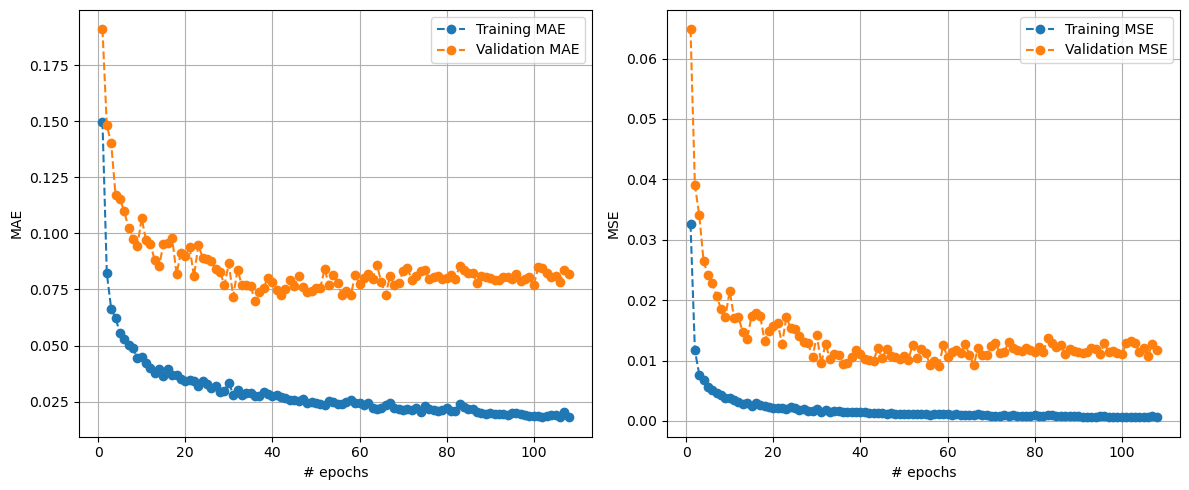

34/34 [==============================] - 1s 26ms/step - loss: 5.9769e-04 - mean_absolute_error: 0.0180 - val_loss: 0.0118 - val_mean_absolute_error: 0.0819


In [54]:
lstm_double_model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

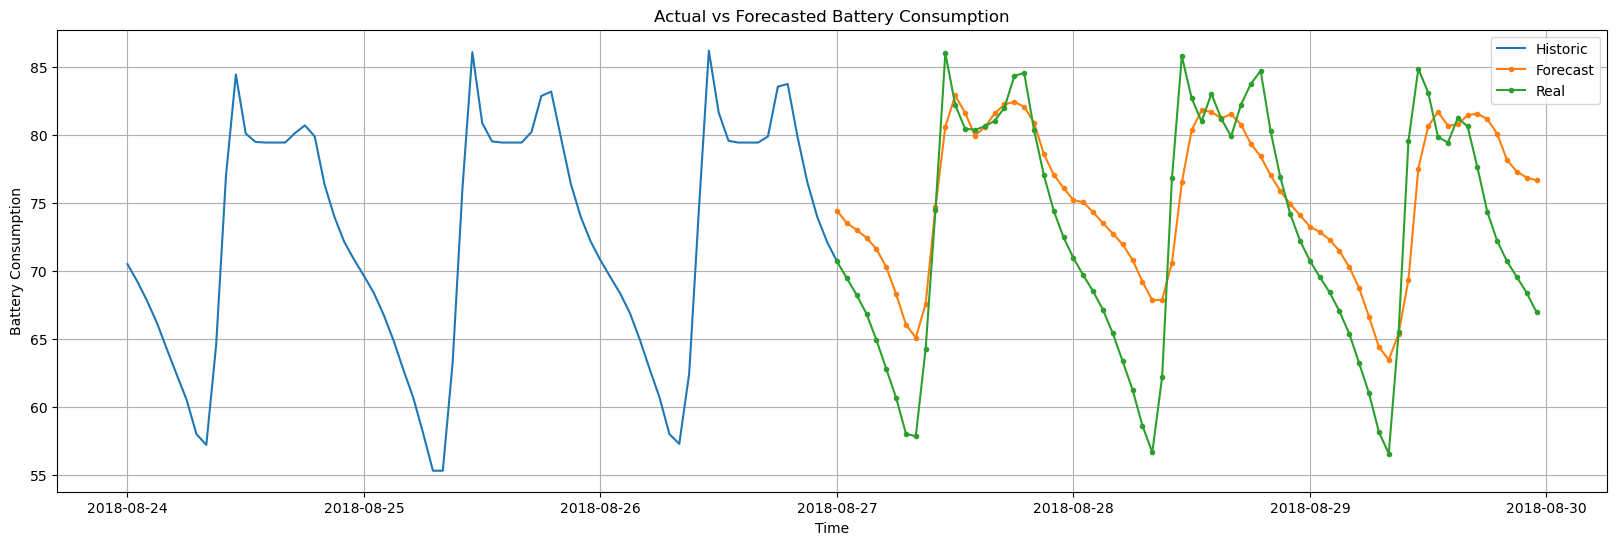

RMSE:  5.352677414210562
MSE:   28.65115550059987
MAE:   4.383965259128147


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [62]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=lstm_double_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Guardamos el modelo

In [63]:
lstm_double_model.save("modelo_LSTM.keras")
lstm_double_model.save("modelo_LSTM.h5")
tf.saved_model.save(lstm_double_model, "modelo_LSTM")

INFO:tensorflow:Assets written to: modelo_LSTM/assets


INFO:tensorflow:Assets written to: modelo_LSTM/assets


In [64]:
# Guardar solo los pesos del modelo
lstm_double_model.save_weights('modelo_LSTM.h5')

### Cuantización

In [65]:
model_load = tf.saved_model.load("modelo_LSTM")

In [59]:
# Select a few hundred samples randomly from the test dataset to calibrate the quantization:
def representative_data_gen():
    # Creamos un onjeto dataset de tensorflow
    data = tf.data.Dataset.from_tensor_slices(X_test)
    #Iteramos sobre el dataset en lotes de tamaño 1, tomando los 100 primeros elementos de X_test
    for i_value in data.batch(1).take(100):
        # Convertimos a float32 los valores i_value
        i_value_f32 = tf.dtypes.cast(i_value, tf.float32)
        # Hacemos que la función sea un generador. En cada iteración se produce una lista que contiene el tensor i_value_f32
        yield [i_value_f32]

In [67]:
data = tf.data.Dataset.from_tensor_slices(X_test)

In [68]:
i = 0
for i_value in data.batch(1).take(100):
        print(i_value)
        i +=1
        print(i)
        i_value_f32 = tf.dtypes.cast(i_value, tf.float32)
        print(f"trans f32: {i_value_f32}")

tf.Tensor(
[[0.36082996 0.228213   0.8156459  0.66045049 0.1362095  0.
  1.         0.        ]], shape=(1, 8), dtype=float64)
1
trans f32: [[0.36082995 0.228213   0.8156459  0.6604505  0.13620949 0.
  1.         0.        ]]
tf.Tensor(
[[0.33822537 0.23728814 0.80068638 0.68710969 0.1362095  0.
  1.         0.04347826]], shape=(1, 8), dtype=float64)
2
trans f32: [[0.33822536 0.23728813 0.80068636 0.6871097  0.13620949 0.
  1.         0.04347826]]
tf.Tensor(
[[0.43066802 0.22447618 0.78376159 0.69033981 0.47701583 0.
  1.         0.08695652]], shape=(1, 8), dtype=float64)
3
trans f32: [[0.43066803 0.22447617 0.78376156 0.6903398  0.47701582 0.
  1.         0.08695652]]
tf.Tensor(
[[0.48026316 0.21193114 0.76469553 0.66484345 0.61350791 0.
  1.         0.13043478]], shape=(1, 8), dtype=float64)
4
trans f32: [[0.48026314 0.21193114 0.7646955  0.66484344 0.6135079  0.
  1.         0.13043478]]
tf.Tensor(
[[0.442139   0.20699319 0.74219758 0.68189845 0.20431424 0.
  1.         0.17391304]]

In [69]:
# Cargar el modelo guardado
TF_MODEL = "modelo_LSTM"

In [70]:
converter = tf.lite.TFLiteConverter.from_saved_model(TF_MODEL)
converter.representative_dataset = tf.lite.RepresentativeDataset(representative_data_gen)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

NameError: name 'representative_data_gen' is not defined

In [65]:
tfl_LSTM_model = converter.convert()

In [56]:
# Guardar el modelo convertido a un archivo .tflite
with open("lstm_model.tflite", "wb") as f:
    f.write(tflite_model_quant)

NameError: name 'tflite_model_quant' is not defined

In [ ]:
size_tfl_model = len(tflite_model_quant)
print(len(tflite_model_quant), "bytes")

In [ ]:
#!apt-get update && apt-get -qq install xxd --> da problemas con el sudo, mejor ejecutar desde la consola
!xxd -i "lstm_model.tflite" > model_lite.h
!sed -i 's/unsigned char/const unsigned char/g' model_lite.h
!sed -i 's/const/alignas(8) const/g' model_lite.h

In [ ]:
def representative_data_gen():
    for i_value in cifar_ds.batch(1).take(100):
        i_value_f32 = tf.dtypes.cast(i_value, tf.float32)
        yield [i_value_f32]

In [ ]:
TF_MODEL = "cifar10"

In [ ]:
tfl_conv = tf.lite.TFLiteConverter.from_saved_model(TF_MODEL)

In [ ]:
tfl_conv.representative_dataset = tf.lite.RepresentativeDataset(representative_data_gen)
tfl_conv.optimizations = [tf.lite.Optimize.DEFAULT]
tfl_conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
tfl_conv.inference_input_type = tf.int8
tfl_conv.inference_output_type = tf.int8

In [ ]:
tfl_model = tfl_conv.convert()

In [ ]:
print(len(tfl_model))

Evaluamos el modelo usando el test_dataset

In [ ]:
tfl_inter = tf.lite.Interpreter(model_content=tfl_model)
tfl_inter.allocate_tensors()

In [ ]:
# get the quantization parameters of the input and output nodes:
i_details = tfl_inter.get_input_details()[0]
o_details = tfl_inter.get_output_details()[0]
i_quant = i_details["quantization_parameters"]
o_quant = o_details["quantization_parameters"]
i_scale = i_quant['scales'][0]
i_zero_point = i_quant['zero_points'][0]
o_scale = o_quant['scales'][0]
o_zero_point = o_quant['zero_points'][0]

In [ ]:
def classify(i_data, o_value):
    input_data = i_value.reshape((1, 32, 32, 3))
    i_value_f32 = tf.dtypes.cast(input_data, tf.float32)
    
    i_value_f32 = i_value_f32 / i_scale + i_zero_point
    i_value_s8 = tf.cast(i_value_f32, dtype=tf.int8)

    tfl_inter.set_tensor(i_details["index"], i_value_s8)
    tfl_inter.invoke()
    o_pred = tfl_inter.get_tensor(o_details["index"])[0]

    return (o_pred - o_zero_point) * o_scale
    

In [ ]:
num_correct_samples = 0

In [ ]:
import numpy as np
for i_value, o_value in zip(val_imgs, val_lables):
    o_pred_f32 = classify(i_value, o_value)
    if np.argmax(o_pred_f32) == o_value:
        num_correct_samples += 1

In [ ]:
total_samples = len(list(val_imgs))
print("Accuracy:", num_correct_samples/total_samples)

In [ ]:
open("cifar10.tflite", "wb").write(tfl_model)
!xxd -i cifar10.tflite > model_cifar10.h
!sed -i 's/unsigned char/const unsigned char/g' model_cifar10.h
!sed -i 's/const/alignas(8) const/g' model_cifar10.h